In [2]:
import os
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [157]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [159]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
# Configs
raw_path = r'C:\Dev_AIWM\jupyter\KNN\raw_data'
crt_path = r'C:\Dev_AIWM\jupyter\KNN\creatures'

In [17]:
knn_df = pd.read_excel(os.path.join(raw_path, "(KNN)DATA.xlsx"))
# df.drop('subjnm', axis=1, inplace=True)
knn_df

,subjnm,sex_sys_val,birthdt,sex,mulg,bir1,bir2,bir3,bir4,prep,...,rcbp2,lgtr2,lggd2,lgbp2,sctr2,scgd2,scbp2,shtr2,shgd2,shbp2
0,ㅂㅈㅂ,1,2013-01-05,NaN,1,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ㅈㅁㄴ,2,2013-01-15,NaN,1,NaN,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ㅇㅈㅇ2,2,2013-01-17,NaN,2,NaN,2.0,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ㅎㅅㄴ2,1,2013-01-18,NaN,2,NaN,2.0,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ㅈㄱㅎ2,2,2013-01-21,NaN,2,NaN,2.0,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14514,ㄱㅅㅎ,1,2019-04-18,1.0,2,NaN,2.0,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14515,ㅊㅇㅇ,1,2019-05-08,1.0,1,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14516,ㄱㅎㅈ,2,2019-06-11,2.0,1,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14517,ㅎㅇㅈ,2,2019-06-19,2.0,1,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
required_cols = [
    'mage', 'sterd2', 'ster', 'htn', 'mulg', 'gaged', 'gagew', 'bwei', 'sex_sys_val', 
    'apgs1', 'apgs5', 'antif', 'pdatir', 'pdad', 'pdadty', 'pdaddt', 'pdaddth', 'addr1', 
    'paddr2', 'ntetdt', 'dthage1', 'dcdhm5', 'ntety', 'ntet', 'subjnm', 'birthdt'
]
new_columns = [
    'Gagew', 'Bbph', 'Apgs5', 'Bbbecrr', 'Btem', 'Bhead', 'Resue', 'Mulg1', 'Merr2', 
    'Bpia3', 'Merr3', 'Resu', 'Resup', 'Mulg3', 'Htn3', 'Bwei', 'mulg4', 'bpia1', 
    'bpia2', 'ster', 'gran', 'delm', 'amni3', 'bhei', 'prom', 'merr4', 'dm1', 'dm3', 
    'resuo', 'htn2', 'htn1', 'merr1', 'apgs1', 'amni2', 'amni1', 'sex_sys_val', 
    'resuh', 'parn', 'mage', 'prep', 'mulg2', 'dm2', 'resui', 'sex_sys_val', 'mage', 
    'gran', 'parn', 'prep', 'prom', 'ster', 'delm', 'gagew', 'apgs1', 'apgs5', 'resu', 
    'resuo', 'resup', 'resui', 'resuh', 'resue', 'bwei', 'bhei', 'bhead', 'btem', 
    'bbph', 'bbbecrr', 'amni1', 'amni2', 'amni3', 'merr1', 'merr2', 'merr3', 'merr4', 
    'mulg1', 'mulg2', 'mulg3', 'mulg4', 'dm1', 'dm2', 'dm3', 'htn1', 'htn2', 'htn3', 
    'bpia1', 'bpia2', 'bpia3', 'bir1', 'bir2', 'bir3', 'bir4', 'iperr'
]

# 모든 칼럼 이름을 소문자로 변환
lower_cols = [col.lower() for col in required_cols + new_columns]

# 중복 제거
final_columns = list(set(lower_cols))

# 데이터에서 필요한 칼럼들만 추출
knn_df_cols = knn_df.columns.intersection(final_columns)
knn_df_ftd = knn_df[knn_df_cols]

# 데이터셋에 없는 칼럼 찾기
missing_columns = list(set(required_cols) - set(knn_df_cols))

# 결과 출력
# print("선택된 칼럼의 데이터:")
print("len(knn_df_cols):", len(knn_df_cols))
print(knn_df_cols)
print()
# print("\n데이터셋에 없는 칼럼:")
print("len(missing_columns):", len(missing_columns))
print(missing_columns)

len(knn_df_cols): 43
Index(['subjnm', 'sex_sys_val', 'birthdt', 'mulg', 'bir1', 'bir2', 'bir3',
       'bir4', 'prep', 'htn', 'prom', 'ster', 'delm', 'sterd2', 'gagew',
       'gaged', 'apgs1', 'apgs5', 'resu', 'resuo', 'resup', 'resui', 'resuh',
       'resue', 'bwei', 'mage', 'gran', 'parn', 'bhei', 'bhead', 'btem',
       'bbph', 'pdad', 'paddr2', 'pdadty', 'pdaddt', 'pdaddth', 'ntet',
       'ntetdt', 'ntety', 'iperr', 'dcdhm5', 'dthage1'],
      dtype='object')

len(missing_columns): 3
['addr1', 'pdatir', 'antif']


In [19]:
knn_df_ftd

,subjnm,sex_sys_val,birthdt,mulg,bir1,bir2,bir3,bir4,prep,htn,...,paddr2,pdadty,pdaddt,pdaddth,ntet,ntetdt,ntety,iperr,dcdhm5,dthage1
0,ㅂㅈㅂ,1,2013-01-05,1,NaN,NaN,NaN,NaN,1,3,...,NaN,2.0,2013-01-07,11.0,2,NaN,1.0,1,NaN,NaN
1,ㅈㅁㄴ,2,2013-01-15,1,NaN,NaN,NaN,NaN,2,3,...,NaN,2.0,2013-01-17,10.0,1,NaN,NaN,1,NaN,NaN
2,ㅇㅈㅇ2,2,2013-01-17,2,NaN,2.0,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN
3,ㅎㅅㄴ2,1,2013-01-18,2,NaN,2.0,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN
4,ㅈㄱㅎ2,2,2013-01-21,2,NaN,2.0,NaN,NaN,2,1,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14514,ㄱㅅㅎ,1,2019-04-18,2,NaN,2.0,NaN,NaN,1,1,...,NaN,2.0,2019-04-21,11.0,1,NaN,NaN,1,NaN,NaN
14515,ㅊㅇㅇ,1,2019-05-08,1,NaN,NaN,NaN,NaN,1,3,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN
14516,ㄱㅎㅈ,2,2019-06-11,1,NaN,NaN,NaN,NaN,1,2,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN
14517,ㅎㅇㅈ,2,2019-06-19,1,NaN,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,1,NaN,NaN,1,NaN,NaN


In [20]:
filtered_knn_df = knn_df_ftd[(knn_df_ftd['ntet'] == 2) | (knn_df_ftd['iperr'] == 2)]

# 결과 출력
print("필터링된 데이터의 크기:", filtered_knn_df.shape)
print(filtered_knn_df)

필터링된 데이터의 크기: (1174, 43)
      subjnm  sex_sys_val     birthdt  mulg  bir1  bir2  bir3  bir4  prep  \
0        ㅂㅈㅂ            1  2013-01-05     1   NaN   NaN   NaN   NaN     1   
17       ㅎㅅㅈ            1  2013-02-09     1   NaN   NaN   NaN   NaN     1   
29      ㅈㅇㅎ2            2  2013-04-27     2   NaN   2.0   NaN   NaN     1   
40      ㅂㅈㅇ1            1  2013-07-13     2   1.0   NaN   NaN   NaN     2   
50       ㄱㅈㅇ            1  2013-03-29     1   NaN   NaN   NaN   NaN     1   
...      ...          ...         ...   ...   ...   ...   ...   ...   ...   
14474    ㄱㅅㅇ            1  2019-12-04     1   NaN   NaN   NaN   NaN     2   
14490    ㅊㅅㅇ            2  2019-07-26     1   NaN   NaN   NaN   NaN     2   
14491   ㄱㅅㅎ2            1  2019-07-26     2   NaN   2.0   NaN   NaN     2   
14500    ㅇㅇㄴ            2  2019-10-03     1   NaN   NaN   NaN   NaN     1   
14507    ㅇㅈㅇ            2  2019-11-30     1   NaN   NaN   NaN   NaN     2   

       htn  ...  paddr2  pdadty      pdaddt  pdadd

In [21]:
filtered_knn_df.to_csv(f"{raw_path}/knn_p2.csv")

In [22]:
for column in filtered_knn_df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {filtered_knn_df[column].dtype}")
    print(f"유니크한 값:")
    print(filtered_knn_df[column].unique())
    print("-" * 40)

칼럼 이름: subjnm
데이터 타입: object
유니크한 값:
['ㅂㅈㅂ' 'ㅎㅅㅈ' 'ㅈㅇㅎ2' 'ㅂㅈㅇ1' 'ㄱㅈㅇ' 'ㅇㅂㄹ' 'ㅊㅇㅎ' 'ㅂㅊㅎ' 'ㅈㅇㅈ3' 'ㅇㅈㅎ1' 'ㅇㄷㅇ2'
 'ㅈㅇㅈ2' 'ㅂㅁㄱ' 'ㅂㅂㄹ' 'ㅊㅈㅇ' 'ㅎㅎㅎ1' 'ㅎㅎㄴ2' 'ㅇㅈㅇ2' 'ㄹㅇㅇ' 'ㅂㄱㅎ' 'ㅇㅇㄹ' 'ㅇㅎㅈ'
 'ㅂㅈㅎ' 'ㅈㅎㅇ' 'ㄱㅎㄴ' 'ㅇㅈㅎ' 'ㅇㅎㅇ' 'ㄱㅎㄹ1' 'ㅁㄱㅇ2' 'ㅇㅊㅅ' 'ㄱㅇㅈ' 'ㅈㅎㄹ' 'ㅇㅇㅈ2'
 'ㅈㅈㅇ' 'ㅇㅅㅇ' 'ㄱㅁㅈ' 'ㅇㅁㅇ1' 'ㅈㅁㅅ1' 'ㅎㅎㅇ' 'ㄱㅈㅎ1' 'ㅇㅎㅎ' 'ㅅㅇㅎ' 'ㅊㄱㅅ' 'ㅈㅎㅈ'
 'ㅂㅇㅈ2' 'ㄱㅈㅎ2' 'ㅇㅎㅅ' 'ㅇㅇㅈ' 'ㄱㅈㅇ2' 'ㄱㄱㅇ' 'ㅊㅈ' 'ㄱㅇ' 'ㅈㅁㅇ' 'ㄱㄱㄹ' 'ㅂㅈㅎ2'
 'ㄱㅇㅅ2' 'ㅂㅎㅈ' 'ㅇㄱㅇ' 'ㅂㅈㅇ' 'ㅇㅂㅇ' 'ㄱㅅㅈ' 'ㅊㅇㅇ' 'ㅇㅈㅅ' 'ㅂㅇㄹ' 'ㅇㅅㅎ' 'ㅅㅂㅎ' 'ㄹㅌㅈ'
 'ㅇㅇㅁ' 'ㅈㅅㅎ' 'ㄱㄷㅇ' 'ㅂㅁㅇ' 'ㄱㅅㅁ3' 'ㅇㅁㄹ' 'ㅇㅈㅇ' 'ㅈㅈㅎ' 'ㄱㅁㅇ' 'ㅂㅅㅇ' 'ㅇㅎㅈㅇㄱ'
 'ㅊㅇㅈ' 'ㅈㅇㅇ' 'ㅂㅅㅎ' 'ㅂㅇㅁ' 'ㄱㅇㄹ' 'ㄱㅈㅇㅇㄱ2' 'ㅇㅅㅇㅇㄱ2' 'ㅊㅇㅁㅇㄱ' 'ㅂㅅㅈ' 'ㅇㅇㅎ'
 'ㅅㅇㅈ1' 'ㄱㅅㅎ' 'ㅊㅎㅅ' 'ㄱㄴㅇ' 'ㅈㅈㅇ1' 'ㄱㅅㅇ2' 'ㅈㅁㅅ' 'ㄱㅊㄹ' 'KHJB' 'ㅊㅈㅎ' 'ㅈㅎㅁ'
 'ㅇㄱㅎ' 'ㄱㅁㅅ' 'ㄱㅅㅎ2' 'ㅎㅁㅎ' 'ㅂㅅㅁ' 'ㅁㅎㅅ1' 'ㅅㅎㄹ2' 'ㄱㅅㅁ' 'ㄹㅅㅅ1' 'ㅈㅅㄹ2' 'ㅂㅇㅅ'
 'ㄹㅅㅅ2' 'ㅂㅅㅎ2' 'ㅎㅅㅂ' 'ㅇㅅㅇ1' 'ㅅㅇㅁ1' 'ㄴㅅㅎ' 'ㅇㅅㅁ1' 'ㄱㅎㅈ' 'ㅅㅈㅎ' 'ㅊㅅㅎ' 'ㄱㅈㅅ'
 'ㄱㅂㄱ' 'ㅈㅂㅇ' 'ㄴㅈㅅ' 'ㅈㅇㅇ2' 'ㅈㅁㅈ2' 'ㄱㅁㅇ2' 'ㅊㅁㄹ2' 'CB' 'ㄱㅈㅎ' 'ㅇㅁㅇ2' 'ㅂㅅㅇ2'
 'ㅇㅁㅈ' '김준서' '정이빈' 'ㄱㅇㅈ1' 'ㅁㅎㅇ' 'ㄱㅅㅇ' 'ㄱㅈㅁ' 'ㅈㅇㄹ' 'ㅎㅈㅇ' 'ㅊㅇㄹ1' 'ㅊㅇㄹ2'
 'ㅇㄷㅇ' 'ㄱㅇㅅ' 'ㅅㄱㅎ1' 'ㅇㅁㅈ1' 'ㅇㅁㅈ2' 'ㅁㅇㅇ' '

In [23]:
df = filtered_knn_df

# 1. 칼럼 'sex_sys_val' 처리
df = df[(df['sex_sys_val'] == 1) | (df['sex_sys_val'] == 2)]
df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})

# 2. 칼럼 'birthdt' 삭제
df.drop('birthdt', axis=1, inplace=True)

# 3. 칼럼 'mulg'로부터 더미 변수 생성
mulg_dummies = pd.get_dummies(df['mulg'], prefix='mulg', drop_first=False)
mulg_dummies.columns = ['mulg_single', 'mulg_twin', 'mulg_triplet']
df = pd.concat([df, mulg_dummies], axis=1)
df.drop('mulg', axis=1, inplace=True)

# 4. 'ntety', 'bir1', 'bir2', 'bir3' 값 변환
df['ntety'] = df['ntety'].fillna(0)
df['bir1'] = df['bir1'].fillna(0)
df['bir2'] = df['bir2'].fillna(0).replace({2: 1})
df['bir3'] = df['bir3'].fillna(0).replace({3: 1})

# 5. 칼럼 'bir4' 삭제
df.drop('bir4', axis=1, inplace=True)

# 6. 칼럼 'prep' 값 변환
df['prep'] = df['prep'].replace({1: 0, 2: 1})

# 7. 칼럼 'htn' 더미 변수 생성
htn_dummies = pd.get_dummies(df['htn'], prefix='htn')
df = pd.concat([df, htn_dummies], axis=1)
df.drop('htn', axis=1, inplace=True)

'''
# 8. 칼럼 'dm' 더미 변수 생성
dm_dummies = pd.get_dummies(df['dm'], prefix='dm')
df = pd.concat([df, dm_dummies], axis=1)
df.drop('dm', axis=1, inplace=True)
'''

# 9-11. 'prom' 및 'ster', 'resu'처리 (Convert to binary + Nan value)
df['prom'] = df['prom'].replace({1: 0, 2: 1, 3: 2})
df['ster'] = df['ster'].replace({1: 0, 2: 1, 3: 2})
df['resu'] = df['resu'].replace({1: 0, 2: 1, 3: 2})

# 11. 'delm' 값 변환
df['delm'] = df['delm'].replace({1: 0, 2: 1})

# 12. 'sterd2' 값 변환
df['sterd2'] = df['sterd2'].fillna(0).replace({2: 1})

# 14-18. 'resuo', 'resup', 'resui', 'resuh', 'resue' 처리
for column in ['resuo', 'resup', 'resui', 'resuh', 'resue']:
    if df[column].isnull().mean() < 0.5:
        df[column] = df[column].fillna(0).replace({1: 0, 2: 1})
    else:
        df.drop(column, axis=1, inplace=True)

# 19. 'pdad' 처리
if df['pdad'].isnull().mean() < 0.5:
    df['pdad'] = df['pdad'].replace({1: 0, 2: 1})
else:
    df.drop('pdad', axis=1, inplace=True)

# 20. 'paddr2' 값 변환
df['paddr2'] = df['paddr2'].fillna(0).replace({2: 1})

# 21. 'pdadty' 더미 변수 생성 후 조건에 따라 삭제
if df['pdadty'].isnull().mean() < 0.5:
    if (df['pdadty'] == 3).mean() < 0.5:
        pdadty_dummies = pd.get_dummies(df['pdadty'], prefix='pdadty')
        df = pd.concat([df, pdadty_dummies], axis=1)
    df.drop('pdadty', axis=1, inplace=True)

# 22. 'ntet', 'iperr' 값 변환
df['ntet'] = df['ntet'].replace({1: 0, 2: 1, 3: 0, 4: 1})
df['iperr'] = df['iperr'].replace({1: 0, 2: 1, 3: 0, 4: 1})

# 23. 'dcdhm5' 값 변환
df['dcdhm5'] = df['dcdhm5'].fillna(0).replace({5: 1})

# 24. Drop columns
df.drop('pdaddt', axis=1, inplace=True)
df.drop('ntetdt', axis=1, inplace=True)
df.drop('pdad', axis=1, inplace=True)
df.drop('paddr2', axis=1, inplace=True)
df.drop('pdadty', axis=1, inplace=True)
df.drop('pdaddth', axis=1, inplace=True)
df.drop('dthage1', axis=1, inplace=True)
df.drop('subjnm', axis=1, inplace=True)


# 데이터 전처리 후 결과 확인
print(df)

ftd_knn_df = df

       sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  gagew  \
0                0   0.0   0.0   0.0     0     0     1     1     0.0     27   
17               0   0.0   0.0   0.0     0     0     1     1     0.0     28   
29               1   0.0   1.0   0.0     0     0     1     1     0.0     27   
40               0   1.0   0.0   0.0     1     0     1     1     0.0     27   
50               0   0.0   0.0   0.0     0     1     1     1     0.0     28   
...            ...   ...   ...   ...   ...   ...   ...   ...     ...    ...   
14474            0   0.0   0.0   0.0     1     0     0     1     0.0     26   
14490            1   0.0   0.0   0.0     1     1     1     0     1.0     25   
14491            0   0.0   1.0   0.0     1     1     1     1     1.0     25   
14500            1   0.0   0.0   0.0     0     0     1     1     1.0     26   
14507            1   0.0   0.0   0.0     1     1     1     1     1.0     27   

       ...  ntet  ntety  iperr  dcdhm5  mulg_single

C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_16260\743477656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})
C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_16260\743477656.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('birthdt', axis=1, inplace=True)


In [24]:
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.000000,2
bir1,0,0.000000,2
bir2,0,0.000000,2
bir3,0,0.000000,2
prep,0,0.000000,2
prom,0,0.000000,3
ster,0,0.000000,3
delm,0,0.000000,2
sterd2,0,0.000000,2
gagew,0,0.000000,15


In [25]:
def fill_na_with_mean(df, columns, decimal_places=None):
    """
    지정된 칼럼의 NaN 값을 해당 칼럼의 평균값으로 채웁니다. 
    필요한 경우 평균값을 정수로 변환하거나 소수점을 지정된 자리수로 반올림합니다.
    """
    for column in columns:
        mean_value = df[column].mean()
        if decimal_places is not None:
            mean_value = round(mean_value, decimal_places)
        elif decimal_places is None and column in integer_columns:
            mean_value = int(round(mean_value))
        df[column] = df[column].fillna(mean_value)
    return df

# 데이터프레임 df를 사용한다고 가정
# 정수로 채워야 하는 칼럼
integer_columns = ['apgs1', 'apgs5']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, integer_columns, decimal_places=0)
# 소수점 두 자리로 채워야 하는 칼럼
decimal_columns = ['bhei', 'bhead', 'btem', 'bbph']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, decimal_columns, decimal_places=2)

ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,ntet,ntety,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,1,1.0,0,0.0,1,0,0,0,0,1
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,1,2.0,0,0.0,1,0,0,0,1,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,0,0.0,1,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,1,1.0,0,0.0,1,0,0,0,1,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,0,0.0,1,0.0,1,0,0,1,0,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,1,2.0,0,0.0,0,1,0,1,0,0
14500,1,0.0,0.0,0.0,0,0,1,1,1.0,26,...,1,2.0,0,0.0,1,0,0,1,0,0


In [27]:
analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
prep,0,0.0,2
prom,0,0.0,3
ster,0,0.0,3
delm,0,0.0,2
sterd2,0,0.0,2
gagew,0,0.0,15


In [26]:
ftd_knn_df.to_csv(f"{raw_path}/knn_p3_fin.csv")

In [123]:
## CLUSTERING

'''
def perform_hierarchical_clustering(df, n_clusters):
    """
    Hierarchical clustering을 수행하고 클러스터 할당 결과를 반환합니다.

    Parameters:
        df (pandas.DataFrame): 클러스터링할 데이터프레임.
        n_clusters (int): 생성할 클러스터의 수.

    Returns:
        array: 각 데이터 포인트의 클러스터 할당 정보.
    """
    # linkage 함수를 사용해 계층적 클러스터 생성
    Z = linkage(df, method='ward')  # Ward 방법을 사용

    # Dendrogram 그리기 (시각화를 위해)
    plt.figure(figsize=(10, 7))
    dendrogram(Z)
    plt.title("Dendrogram")
    plt.xlabel('Data Points')
    plt.ylabel('Euclidean Distance')
    plt.show()

    # fcluster 함수를 사용해 데이터 포인트에 클러스터 라벨 할당
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    return clusters
'''

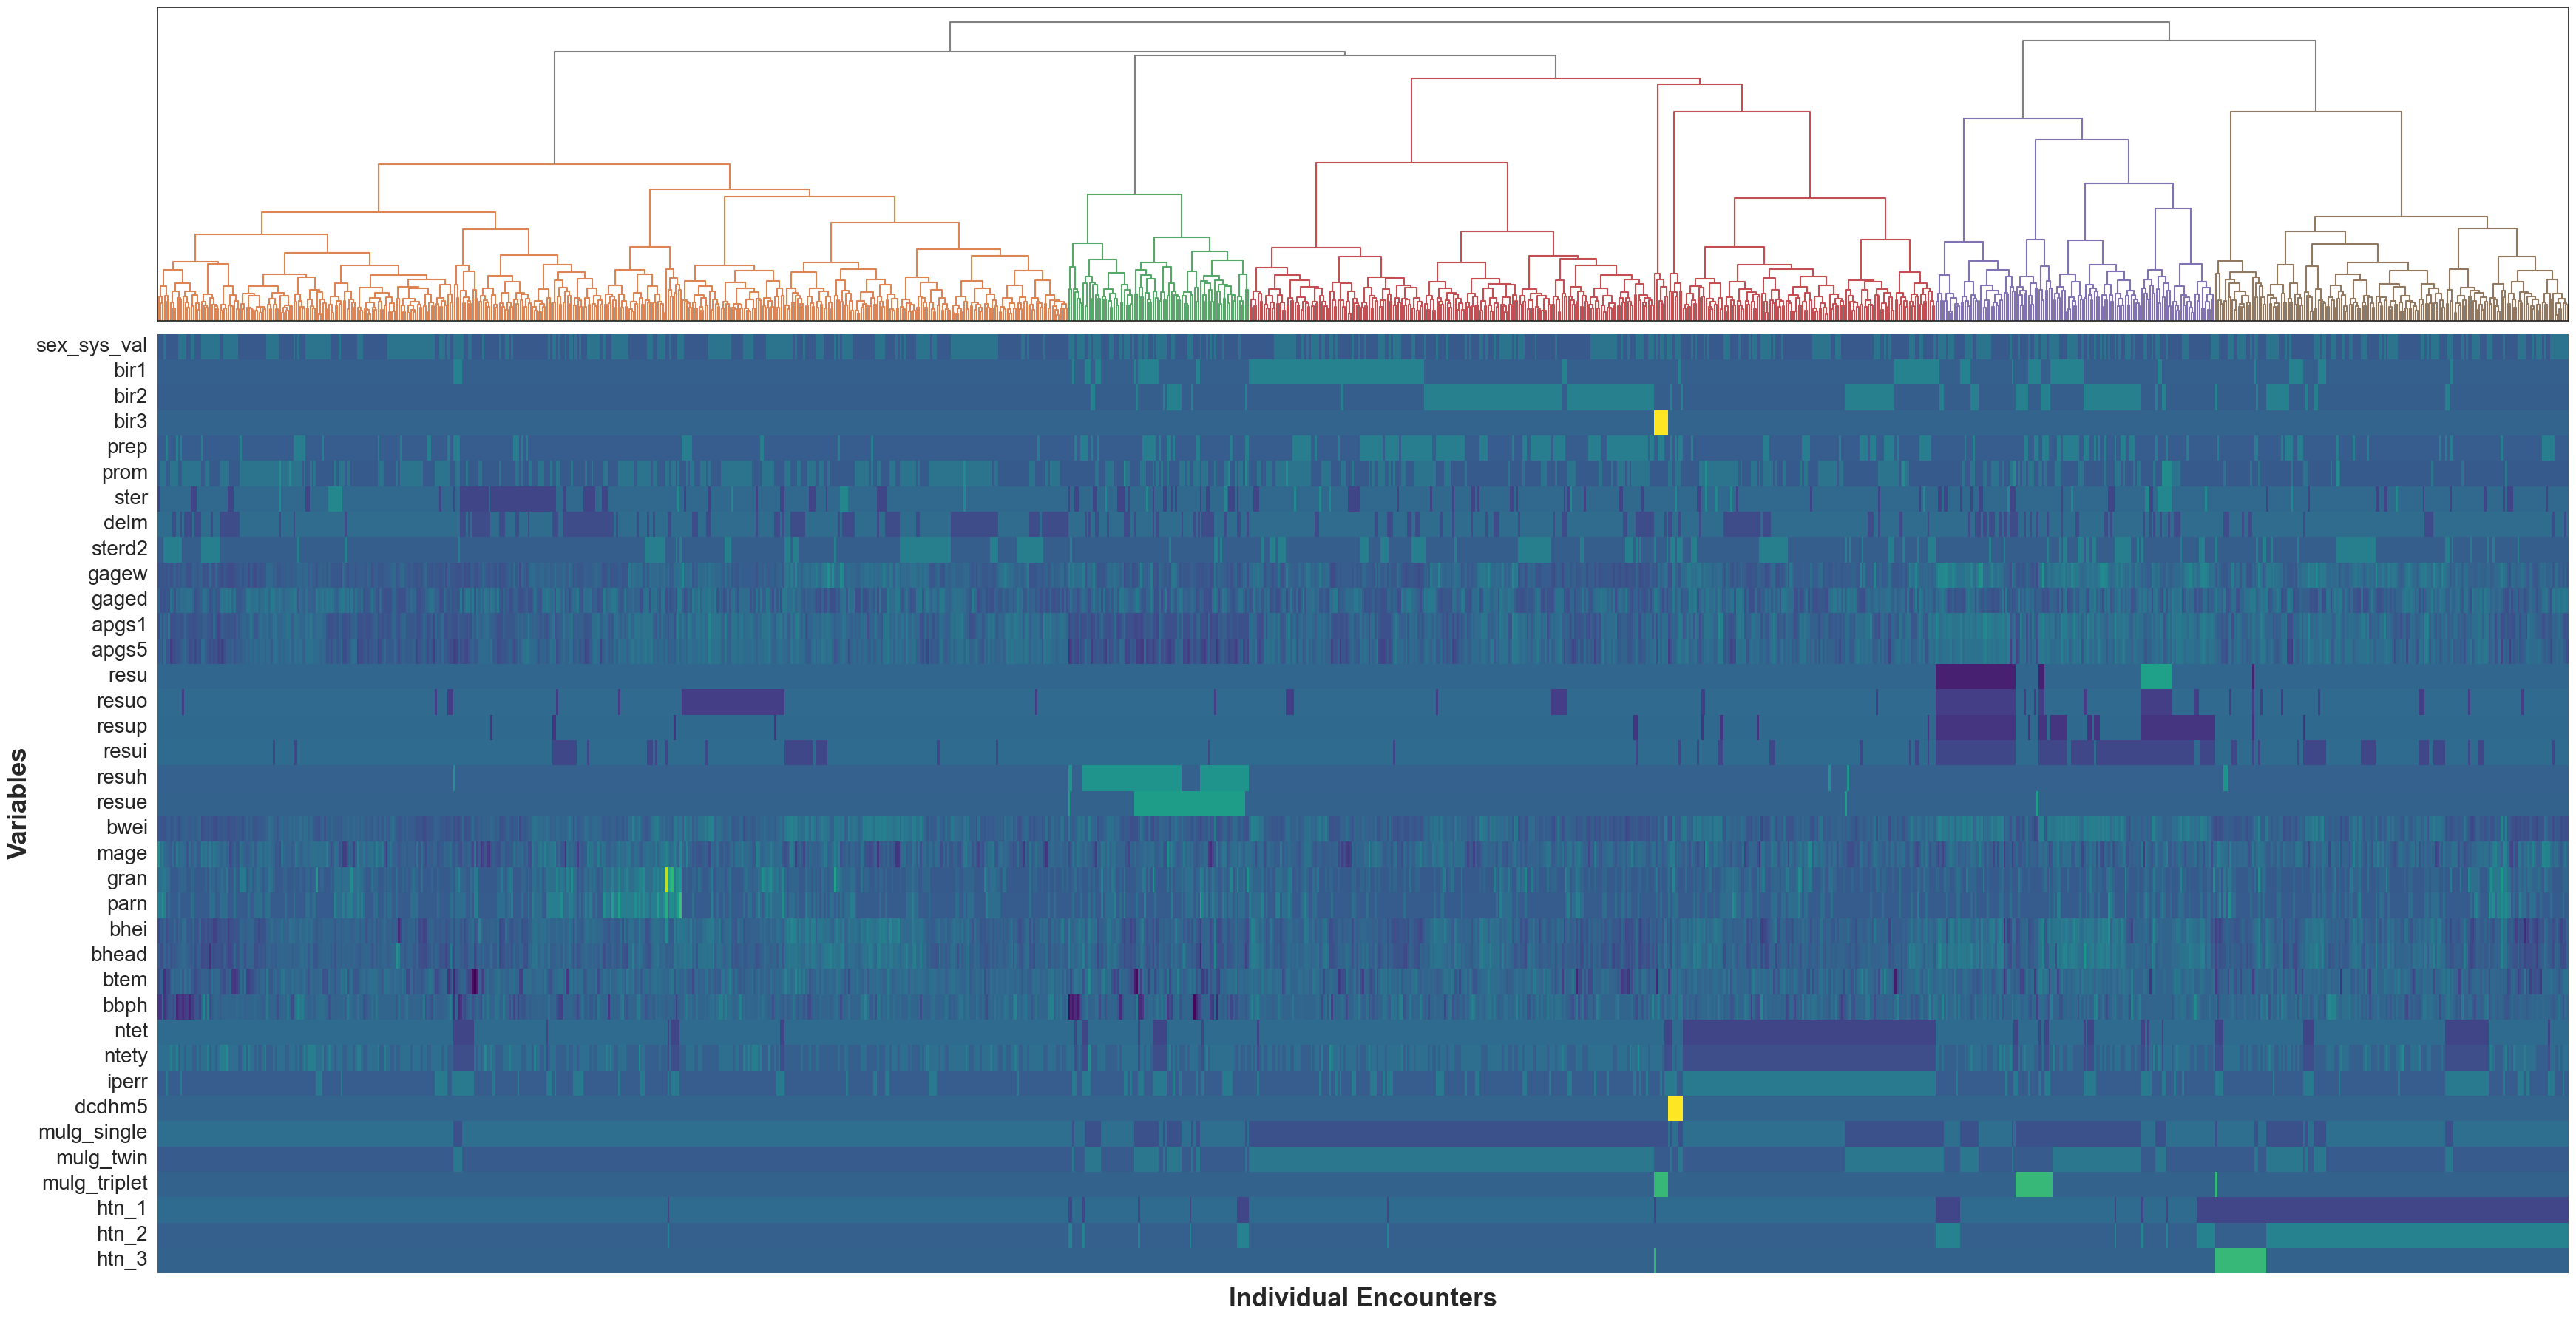

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [4]:
# Data import
ftd_knn_df = pd.read_csv(f"{raw_path}/knn_p3_fin.csv")
ftd_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
ftd_knn_df.set_index('subj_ind', inplace=True)

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ftd_knn_df)

# scaled_data 반영
ftd_scd_knn_df = pd.DataFrame(scaled_data, index=ftd_knn_df.index, columns=ftd_knn_df.columns)

# 계층적 클러스터링 수행
Z_objects = linkage(ftd_scd_knn_df, method='ward')
cluster_labels = fcluster(Z_objects, t=5, criterion='maxclust')    # 클러스터 할당
ftd_knn_df['Cluster_Labels'] = cluster_labels    # 클러스터 라벨을 데이터프레임에 추가

# 시각화 설정
sns.set(style="white")

# Figure 설정 with specified dimensions for each subplot
fig, (ax1, ax2) = plt.subplots(2, 1,
                               figsize=(35, 18),  # 전체 Figure의 크기 조정
                               gridspec_kw={'height_ratios': [1, 3]}  # 각 subplot의 높이 비율 조정
                              )

# 덴드로그램
dendro_objects = dendrogram(Z_objects
                            , ax=ax1
                            , orientation='top'
                            , color_threshold=0.815 * max(Z_objects[:, 2])
                            , above_threshold_color='grey'
                           )
ax1.set_xticks([])
ax1.set_yticks([])

# 데이터 정렬 및 히트맵 추가
sorted_idx = dendro_objects['leaves']
data_sorted = ftd_scd_knn_df.iloc[sorted_idx, :]  # 마지막 컬럼(Cluster_Labels) 제외

# 히트맵
sns.heatmap(data_sorted.T
            , ax=ax2
            , cbar=False
            , cmap='viridis'
            , yticklabels=ftd_scd_knn_df.columns[:]
           )
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')  # X 레이블의 글자 크기 및 두께 조절
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')  # Y 레이블의 글자 크기 및 두께 조절
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)  # Y축 레이블의 글자 크기 조절

plt.tight_layout()
plt.show()

# 결과 출력
print(ftd_knn_df)

In [36]:
print(ftd_knn_df, '\n\n', ftd_scd_knn_df)

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [37]:
filtered_knn_df = pd.read_csv(f"{raw_path}/knn_p1.csv")
filtered_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
filtered_knn_df.set_index('subj_ind', inplace=True)
filtered_knn_df.drop('subjnm', axis=1, inplace=True)
filtered_knn_df.rename(columns={'dthage1': 'death_label'}, inplace=True)
filtered_knn_df['death_label'] = filtered_knn_df['death_label'].notna().astype(int)

dthage_data = filtered_knn_df['death_label']
print(dthage_data)

subj_ind
0        0
17       0
29       0
40       0
50       0
        ..
14474    0
14490    0
14491    0
14500    0
14507    0
Name: death_label, Length: 1174, dtype: int32


In [38]:
ftd_knn_df = ftd_knn_df.merge(dthage_data, left_index=True, right_index=True, how='left')
ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3,Cluster_Labels,death_label
subj_ind,,,,,,,,,,,,,,,,,,,,,
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,0,0.0,1,0,0,0,0,1,5,0
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,0,0.0,1,0,0,0,1,0,5,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,3,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,2,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,1,0.0,1,0,0,1,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,0,0.0,1,0,0,0,1,0,5,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,1,0.0,1,0,0,1,0,0,3,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,0,0.0,0,1,0,1,0,0,3,0


In [39]:
ftd_knn_df.describe()
ftd_knn_df.to_csv(f"{crt_path}/knn_standardised_p2+dthage_M01.csv")

In [43]:
## WILCOXON TESTING
ftd_knn_df = pd.read_csv(f"{crt_path}/knn_standardised_p2+dthage_M01.csv", index_col='subj_ind')

# 결과 저장을 위한 DataFrame 초기화
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대해 계산
for i in range(1, 6):
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    outside_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in ftd_knn_df.columns[:-2]:  # 'Cluster_Labels'와 'death_label' 컬럼 제외
        u_stat, p_value = mannwhitneyu(cluster_data[column], outside_data[column], alternative='two-sided')
        mean_val = cluster_data[column].mean()
        std_dev = cluster_data[column].std()

        # 평균과 표준편차 저장
        stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
        
        # p-value의 조건에 따라 형식 지정
        if p_value < 0.05:
            if p_value < 0.0001:
                formatted_p_value = f"{p_value:.4e}"  # 매우 작은 값에 대해 지수 표현식 사용
            else:
                formatted_p_value = f"{p_value:.4f}"
            p_values[column] = formatted_p_value
        else:
            p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과 출력
print("Mean and Standard Deviation:")
print(stats_df)
print("\nP-values:")
print(p_values_df)

Mean and Standard Deviation:
                        Cluster 1            Cluster 2            Cluster 3  \
sex_sys_val       0.4673 ± 0.4995      0.4545 ± 0.5008      0.3862 ± 0.4876   
bir1              0.0090 ± 0.0947      0.2273 ± 0.4215      0.3263 ± 0.4696   
bir2              0.0000 ± 0.0000      0.1477 ± 0.3569      0.4072 ± 0.4920   
bir3              0.0000 ± 0.0000      0.0000 ± 0.0000      0.0210 ± 0.1435   
prep              0.0790 ± 0.2701      0.2614 ± 0.4419      0.4311 ± 0.4960   
prom              0.5282 ± 0.5132      0.4318 ± 0.5631      0.4431 ± 0.5153   
ster              0.8488 ± 0.4433      0.7841 ± 0.4901      0.9371 ± 0.3364   
delm              0.6569 ± 0.4753      0.7273 ± 0.4479      0.7964 ± 0.4033   
sterd2            0.1919 ± 0.3942      0.0568 ± 0.2328      0.2515 ± 0.4345   
gagew            25.7901 ± 2.1481     25.7386 ± 2.3611     25.7964 ± 2.2342   
gaged             2.8962 ± 2.0097      2.6705 ± 1.8860      2.8982 ± 2.0243   
apgs1             3.731

In [48]:
stats_df.to_excel(f"{crt_path}/knn_wilcoxon_M01_wilcoxon.xlsx")
p_values_df.to_excel(f"{crt_path}/knn_wilcoxon_M01_p_val.xlsx")

In [41]:
## DEATH RATIO
results_df = pd.DataFrame()

# 각 클러스터의 사망률 계산
for i in range(1, 6):
    # 해당 클러스터 데이터 추출
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    total_count = cluster_data.shape[0]
    death_count = cluster_data['death_label'].sum()
    
    # 사망률 계산
    mortality_rate = (death_count / total_count) * 100
    
    # 결과 저장
    results_df.loc[f'Cluster {i}', 'Total'] = total_count
    results_df.loc[f'Cluster {i}', 'Deaths'] = death_count
    results_df.loc[f'Cluster {i}', 'Mortality Rate'] = f"{mortality_rate:.2f}%"
    results_df.loc[f'Cluster {i}', 'Deaths / Total'] = f"{death_count} / {total_count}"

# 결과 출력
print(results_df)

           Total  Deaths Mortality Rate Deaths / Total
Cluster 1  443.0     6.0          1.35%        6 / 443
Cluster 2   88.0     1.0          1.14%         1 / 88
Cluster 3  334.0     4.0          1.20%        4 / 334
Cluster 4  136.0     0.0          0.00%        0 / 136
Cluster 5  172.0     1.0          0.58%        1 / 172



1. blank value & nan value 50% 이하 : 소거
2. 칼럼 '*dt' 등 disease related columns, 'ntet', 'iperr', 'subjnm' 제거
3. 데이터 값들을 one-hot encoding, vector화

4. clustering